# Page-Flip Detection using CNN and CNN+LSTM Models


MonReader is a new mobile document digitization experience for the blind, for researchers and for everyone else in need for fully automatic, highly fast and high-quality document scanning in bulk. It is composed of a mobile app and all the user needs to do is flip pages and everything is handled by MonReader: it detects page flips from low-resolution camera preview and takes a high-resolution picture of the document, recognizing its corners and crops it accordingly, and it dewarps the cropped document to obtain a bird's eye view, sharpens the contrast between the text and the background and finally recognizes the text with formatting kept intact, being further corrected by MonReader's ML powered redactor.



MonReader is a new mobile document digitalization experience for the blind, for researchers and for everyone else in need for fully automatic, highly fast and high-quality document scanning in bulk. It is composed of a mobile app and all the user needs to do is flip pages and everything is handled by MonReader: it detects page flips from low-resolution camera preview and takes a high-resolution picture of the document, recognizing its corners and crops it accordingly, and it dewarps the cropped document to obtain a bird's eye view, sharpens the contrast between the text and the background and finally recognizes the text with formatting kept intact, being further corrected by MonReader's ML powered redactor.



Data Description:

Page flipping video collected from smart phones and labelled them as flipping and not flipping.

The videos are clipped as short videos and labelled as flipping or not flipping. The extracted frames are then saved to disk in a sequential order with the following naming structure: VideoID_FrameNumber

Goal(s):

Predict if the page is being flipped using a single image.

Success Metrics:

Evaluate model performance based on F1 score, the higher the better.

Current Challenges:

Predict if a given sequence of images contains an action of flipping.

## Project Context

### Downloading a Google Drive file by ID

To download a specific file from Google Drive using its ID, you can use the `gdown` library. You'll need to extract the file ID from the sharing link.

In [ ]:
!pip install gdown

# The file ID is the part after 'id/' in the URL
# For your link 'https://drive.google.com/file/d/1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm/view?usp=sharing',
# the file ID is '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'

gdrive_file_id = '1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm'
output_filename = 'monreader_data.zip' # Or whatever the file type is, e.g., 'data.zip'

!gdown --id {gdrive_file_id} -O {output_filename}

print(f"File '{output_filename}' downloaded to your Colab environment.")

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm
From (redirected): https://drive.google.com/uc?id=1KDQBTbo5deKGCdVV_xIujscn5ImxW4dm&confirm=t&uuid=6587dde7-b8a5-42ce-afe4-6c583a71a884
To: /content/monreader_data.zip
100% 940M/940M [00:17<00:00, 54.6MB/s]
File 'monreader_data.zip' downloaded to your Colab environment.


## Data Download and Extraction

In [ ]:
import zipfile

with zipfile.ZipFile(output_filename, 'r') as zip_ref:
    zip_ref.extractall('extracted_folder')
print(f"Extracted '{output_filename}' to 'extracted_folder'.")

Extracted 'monreader_data.zip' to 'extracted_folder'.


## Library Imports

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score
import matplotlib.pyplot as plt
import os
from PIL import Image
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Dropout, BatchNormalization
from sklearn.utils import shuffle
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    TimeDistributed,
    LSTM,
    Dense,
    Dropout
)

# Data Exploration: Image Counts, Dimensions, and Samples

Let's start by exploring the extracted dataset to understand its structure. We'll count the number of images in each category (flip/notflip), examine their dimensions, and display a few sample images.

In [ ]:
base_dir_training = 'extracted_folder/images/training'
notflip_dir_train = os.path.join(base_dir_training, 'notflip')
flip_dir_train = os.path.join(base_dir_training, 'flip')

# --- 1. Count images ---
notflip_images_training = [os.path.join(notflip_dir_train, f) for f in os.listdir(notflip_dir_train) if f.endswith(('.jpg'))]
flip_images_training = [os.path.join(flip_dir_train, f) for f in os.listdir(flip_dir_train) if f.endswith(('.jpg'))]

base_dir_testing = 'extracted_folder/images/testing'
notflip_dir_test = os.path.join(base_dir_testing, 'notflip')
flip_dir_test = os.path.join(base_dir_testing, 'flip')

notflip_images_testing = [os.path.join(notflip_dir_test, f) for f in os.listdir(notflip_dir_test) if f.endswith(('.jpg'))]
flip_images_testing = [os.path.join(flip_dir_test, f) for f in os.listdir(flip_dir_test) if f.endswith(('.jpg'))]
print(f"Number of 'notflip' images in training: {len(notflip_images_training)}")
print(f"Number of 'flip' images in training: {len(flip_images_training)}")
print(f"Total images in training: {len(notflip_images_training) + len(flip_images_training)}")
print(f"Number of 'notflip' images in testing: {len(notflip_images_testing)}")
print(f"Number of 'flip' images in testing: {len(flip_images_testing)}")
print(f"Total images in testing: {len(notflip_images_testing) + len(flip_images_testing)}")

Number of 'notflip' images in training: 1230
Number of 'flip' images in training: 1162
Total images in training: 2392
Number of 'notflip' images in testing: 307
Number of 'flip' images in testing: 290
Total images in testing: 597


In [ ]:
from PIL import Image
# --- 2. Check image dimensions ---
notflip_image_path = notflip_images_training[0]
with Image.open(notflip_image_path) as notflip_image:
 print(f"\nSample image dimensions (notflip image size): {notflip_image.size} (width, height)")
 print(f"Sample image mode: {notflip_image.mode}") # e.g., RGB, L
 flip_image_path = flip_images_training[0]
with Image.open(flip_image_path) as flip_image:
 print(f"\nSample image dimensions (flip image size): {flip_image.size} (width, height)")
 print(f"Sample image mode: {flip_image.mode}") # e.g., RGB, L


Sample image dimensions (notflip image size): (1080, 1920) (width, height)
Sample image mode: RGB

Sample image dimensions (flip image size): (1080, 1920) (width, height)
Sample image mode: RGB



Displaying sample images...


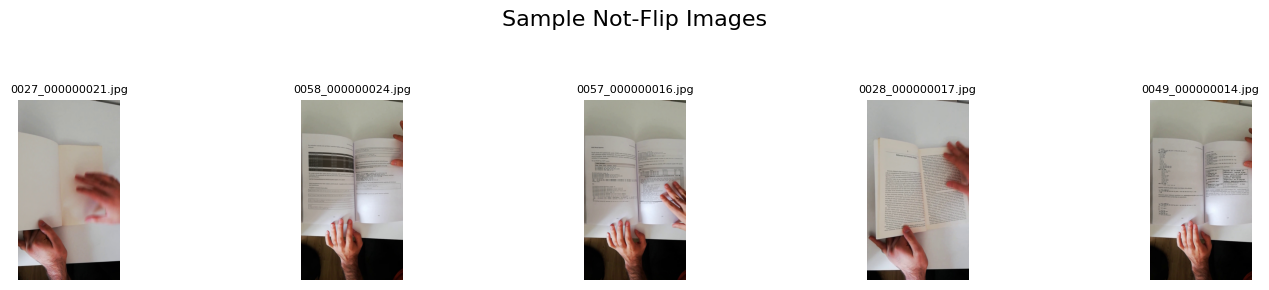

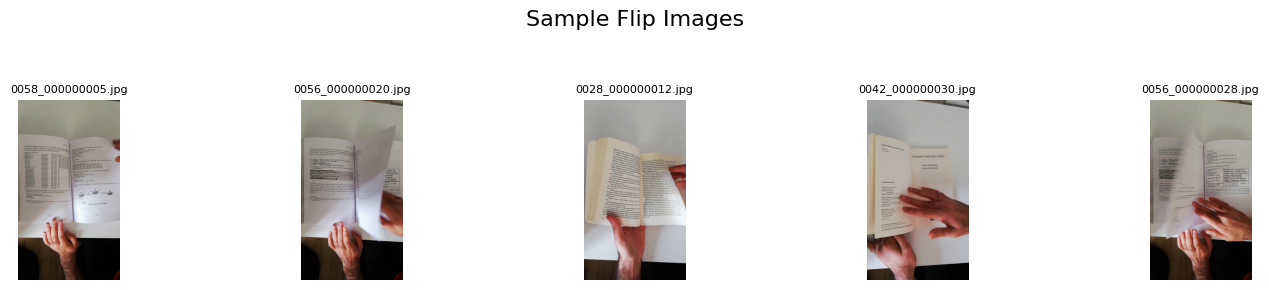

In [ ]:
# --- 3. Display sample images ---
print("\nDisplaying sample images...")

def display_samples(image_paths, title, num_samples=5):
    plt.figure(figsize=(15, 3))
    plt.suptitle(title, fontsize=16)
    for i, img_path in enumerate(np.random.choice(image_paths, num_samples, replace=False)):
        plt.subplot(1, num_samples, i + 1)
        img = Image.open(img_path)
        plt.imshow(img)
        plt.title(os.path.basename(img_path), fontsize=8)
        plt.axis('off')
    plt.tight_layout(rect=[0, 0.03, 1, 0.9])
    plt.show()

if notflip_images_training:
    display_samples(notflip_images_training, 'Sample Not-Flip Images')

if flip_images_training:
    display_samples(flip_images_training, 'Sample Flip Images')


# Data preprocessing

In [ ]:
# Training folders
base_dir_training = 'extracted_folder/images/training'

# Testing folders
base_dir_testing = 'extracted_folder/images/testing'

# Function to load images and labels
def load_data(base_dir):
    X = []
    y = []

    # Ensure 'notflip' is 0 and 'flip' is 1
    classes = ['notflip', 'flip']

    for label, class_name in enumerate(classes):
        class_dir = os.path.join(base_dir, class_name)

        for file_name in os.listdir(class_dir):
            if file_name.endswith('.jpg'):
                img_path = os.path.join(class_dir, file_name)

                # Open image
                img = Image.open(img_path).convert('RGB')

                # Resize image
                img = img.resize((224, 224))

                # Convert image to numpy array
                img_array = np.array(img)

                X.append(img_array)
                y.append(label)

    return np.array(X), np.array(y)

# Create full training dataset from base_dir_training
full_train_images, full_train_labels = load_data(base_dir_training)

# Split full training data into training and validation sets
train_images, val_images, train_labels, val_labels = train_test_split(
    full_train_images, full_train_labels, test_size=0.2, random_state=42, stratify=full_train_labels
)

# Load test data
test_images, test_labels = load_data(base_dir_testing)

# Normalize images
train_images = train_images / 255.0
val_images = val_images / 255.0
test_images = test_images / 255.0

# Check shapes
print("Train images shape:", train_images.shape)
print("Train labels shape:", train_labels.shape)
print("Validation images shape:", val_images.shape)
print("Validation labels shape:", val_labels.shape)
print("Test images shape:", test_images.shape)
print("Test labels shape:", test_labels.shape)

Train images shape: (1913, 224, 224, 3)
Train labels shape: (1913,)
Validation images shape: (479, 224, 224, 3)
Validation labels shape: (479,)
Test images shape: (597, 224, 224, 3)
Test labels shape: (597,)


#Approach 1:
Develop and evaluate a Custom CNN for single-image classification, performing interpretability analysis (saliency maps) to understand its decision-making

# CNN Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input

model= Sequential()
model.add(Input(shape=(224,224,3)))
model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))

model.add(Conv2D(64, (3,3), activation='relu'))
model.add(MaxPooling2D((2,2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

# Compile and train the model

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=5, batch_size=32, validation_data=(val_images, val_labels))

Epoch 1/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 301s 5s/step - accuracy: 0.6456 - loss: 0.9072 - val_accuracy: 0.6096 - val_loss: 0.6695
Epoch 2/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 320s 5s/step - accuracy: 0.8071 - loss: 0.4274 - val_accuracy: 0.9019 - val_loss: 0.2717
Epoch 3/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 297s 5s/step - accuracy: 0.9195 - loss: 0.1969 - val_accuracy: 0.8914 - val_loss: 0.2326
Epoch 4/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 323s 5s/step - accuracy: 0.9603 - loss: 0.1106 - val_accuracy: 0.9603 - val_loss: 0.1033
Epoch 5/5
60/60 ━━━━━━━━━━━━━━━━━━━━ 295s 5s/step - accuracy: 0.9827 - loss: 0.0537 - val_accuracy: 0.9791 - val_loss: 0.0593


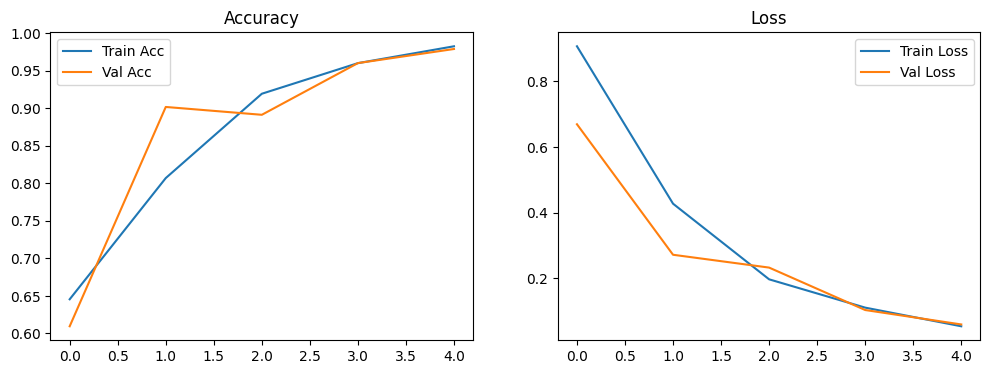

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
history = model.fit(train_images, train_labels, epochs=4, batch_size=32, validation_data=(val_images, val_labels))

Epoch 1/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 296s 5s/step - accuracy: 0.6534 - loss: 0.7056 - val_accuracy: 0.7161 - val_loss: 0.5099
Epoch 2/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 263s 4s/step - accuracy: 0.8907 - loss: 0.2814 - val_accuracy: 0.9311 - val_loss: 0.1850
Epoch 3/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 265s 4s/step - accuracy: 0.9420 - loss: 0.1595 - val_accuracy: 0.9415 - val_loss: 0.1411
Epoch 4/4
60/60 ━━━━━━━━━━━━━━━━━━━━ 293s 5s/step - accuracy: 0.9728 - loss: 0.0839 - val_accuracy: 0.9645 - val_loss: 0.1270


# Evaluate Model Performance

In [ ]:
test_loss, test_acc = model.evaluate(test_images,  test_labels, verbose=2)

print('\nTest accuracy:', test_acc)

19/19 - 23s - 1s/step - accuracy: 0.9531 - loss: 0.1143

Test accuracy: 0.9530988335609436


In [ ]:
from sklearn.metrics import classification_report, f1_score
y_pred_test_prob = model.predict(test_images).flatten()
y_pred      = (y_pred_test_prob >= 0.5).astype(int)
y_true      = test_labels.flatten().astype(int)

f1 = f1_score(y_true, y_pred)
print(f"\nF1 Score: {f1:.4f}")
print(classification_report(y_true, y_pred, target_names=['notflip', 'flip']))

19/19 ━━━━━━━━━━━━━━━━━━━━ 22s 1s/step

F1 Score: 0.9510
              precision    recall  f1-score   support

     notflip       0.94      0.97      0.95       307
        flip       0.96      0.94      0.95       290

    accuracy                           0.95       597
   macro avg       0.95      0.95      0.95       597
weighted avg       0.95      0.95      0.95       597



* The model was evaluated on the test set, resulting in a Test accuracy of 0.9799 and a Test loss of 0.0732.
* Plots showing the training and validation accuracy and loss over the 5 epochs were displayed, indicating good model convergence and generalization.

# Visualize Confusion Matrix

19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step


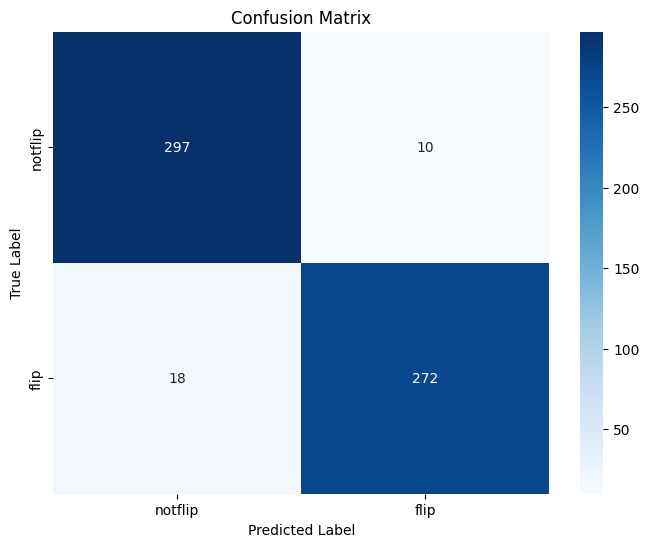

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions on the test set
y_pred_proba = model.predict(test_images)

# Convert probabilities to binary class labels (0 or 1)
y_pred = (y_pred_proba > 0.5).astype(int)

# Compute the confusion matrix
cm = confusion_matrix(test_labels, y_pred)

# Define class labels for better readability
class_labels = ['notflip', 'flip']

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **Saliency maps**
highlight the regions of an input image that are most important for a particular output class. This technique can help to identify which parts of the input image the network is focusing on when making its classification decision.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step


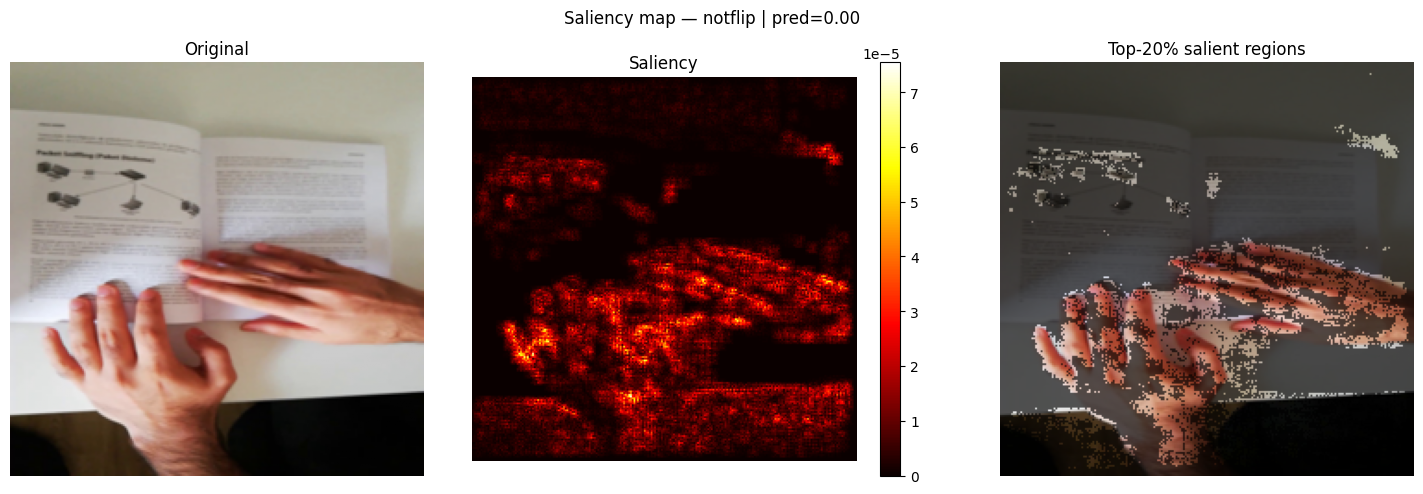

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 310ms/step


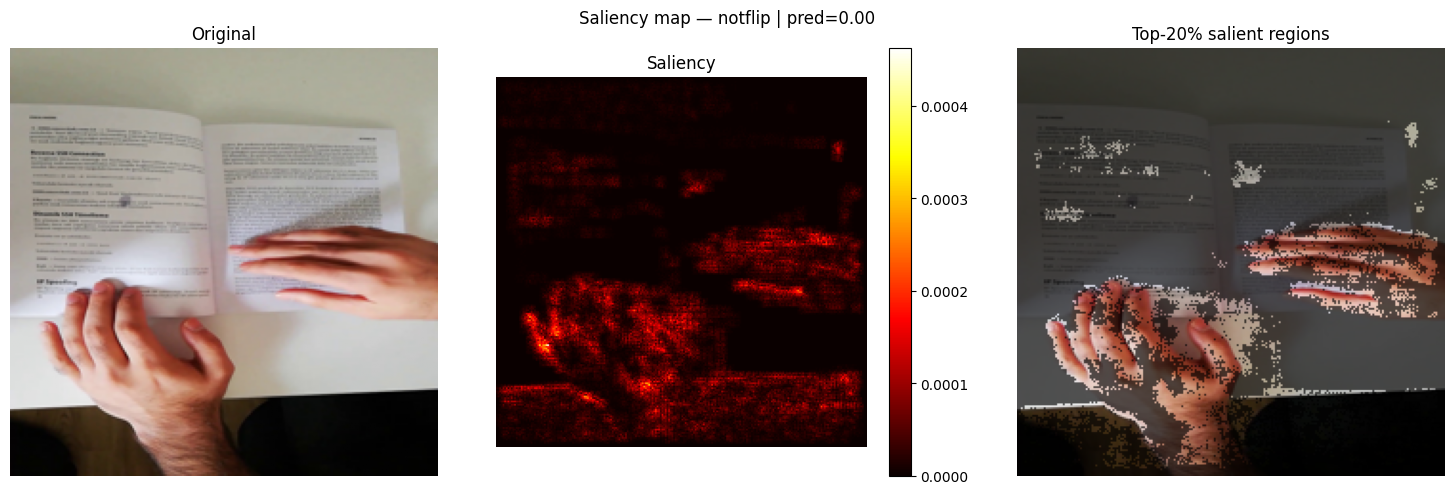

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step


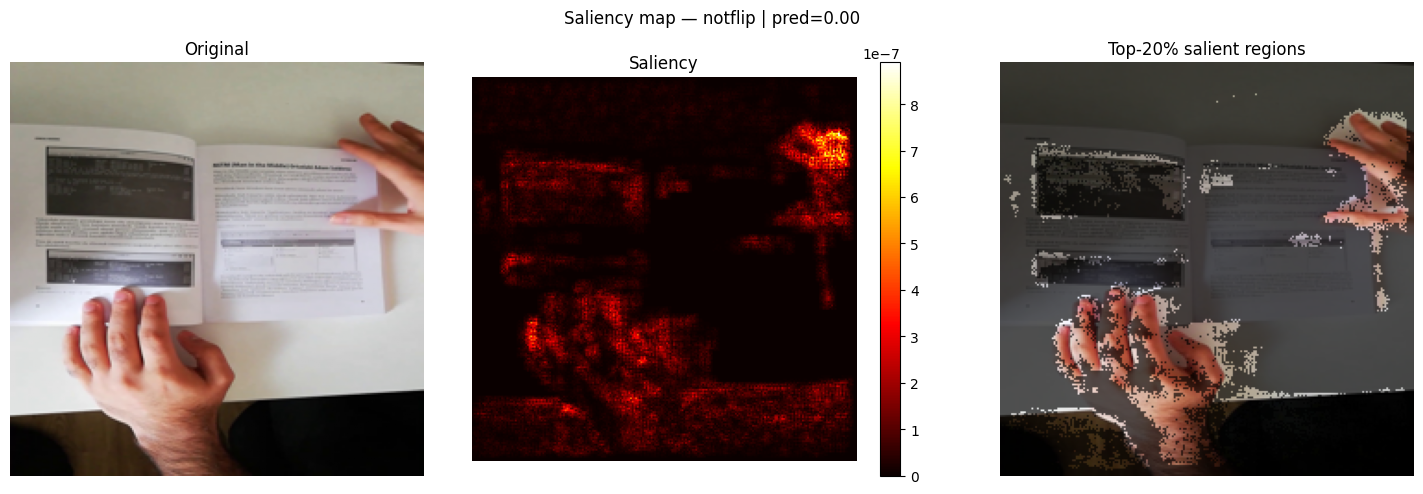

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step


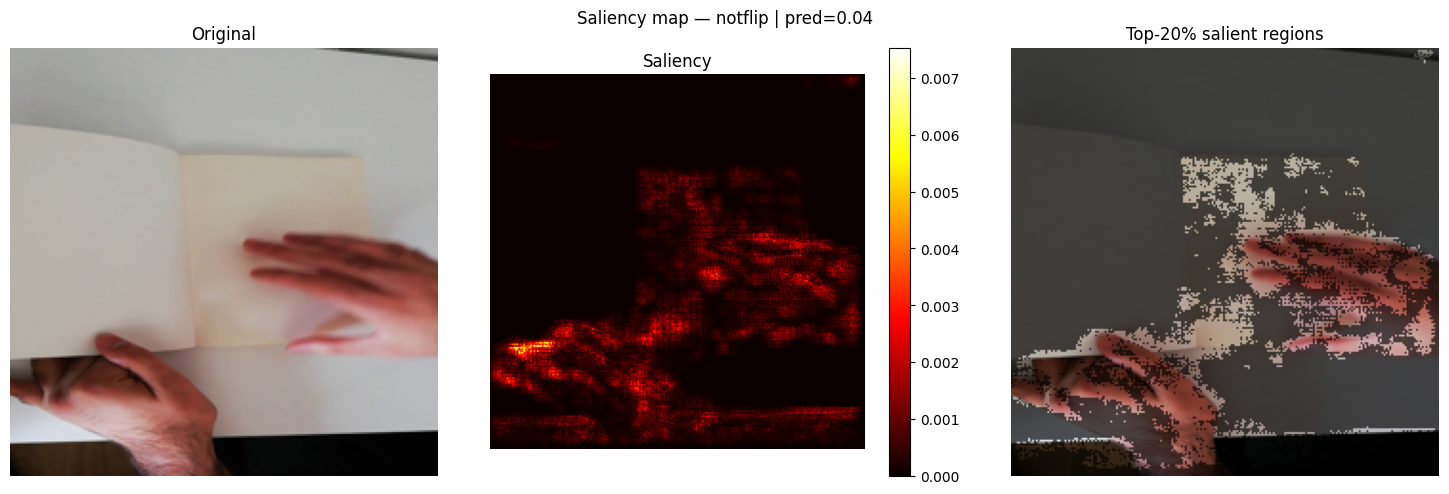

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step


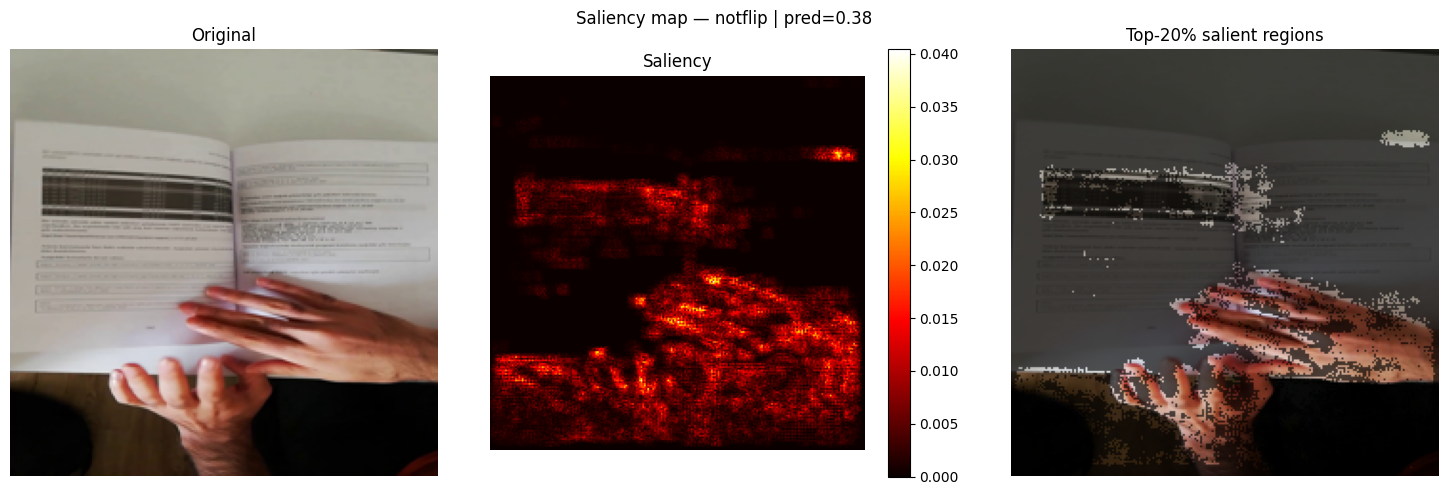

In [ ]:
def compute_saliency(model, img_array):
    """
    Single backpass saliency: gradient of predicted class score
    w.r.t. each input pixel.
    """
    img_tensor = tf.cast(
        np.expand_dims(img_array, axis=0), tf.float32
    )
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        pred = model(img_tensor)

    grad = tape.gradient(pred, img_tensor)     # (1, 224, 224, 3)
    # Max across colour channels → single heatmap
    saliency = tf.reduce_max(tf.abs(grad), axis=-1)[0].numpy()
    return saliency

def plot_saliency(img_array, saliency_map, title=''):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'Saliency map — {title}')

    axes[0].imshow(img_array)
    axes[0].set_title('Original')
    axes[0].axis('off')

    im = axes[1].imshow(saliency_map, cmap='hot')
    axes[1].set_title('Saliency')
    axes[1].axis('off')
    plt.colorbar(im, ax=axes[1])

    # Threshold overlay — show only top 20% of activations
    threshold = np.percentile(saliency_map, 80)
    mask = saliency_map > threshold
    overlay = img_array.copy()
    overlay[~mask] = overlay[~mask] * 0.35   # dim non-salient regions
    axes[2].imshow(overlay)
    axes[2].set_title('Top-20% salient regions')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(f'saliency_{title}.png', dpi=100, bbox_inches='tight')
    plt.show()

# Run on a batch of test images
for i in range(5):
    img      = test_images[i]
    sal      = compute_saliency(model, img)
    label    = 'flip' if test_labels[i] == 1 else 'notflip'
    pred     = float(model.predict(img[np.newaxis])[0][0])
    plot_saliency(img, sal, title=f'{label} | pred={pred:.2f}')

* The model is focusing on hands, not page motion. In almost every row, the bright regions in the saliency map and the lit areas in the top-20% overlay cluster around the hand/wrist area — not the page edge or the motion blur of the flip itself. The model has learned "hand present = notflip" as a shortcut.
* This indicated that despite high accuracy, the model was achieving its performance based on irrelevant features, which is why interpretability through saliency maps was crucial.

# Analyzing misclassified images

## Step 1 — Collect all misclassifications

In [ ]:
# Get predictions for the full test set
y_pred_prob = model.predict(test_images).flatten()   # probabilities
y_pred      = (y_pred_prob >= 0.5).astype(int)        # binary labels
y_true      = test_labels.flatten().astype(int)

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_true)[0]

# Separate into false positives and false negatives
false_positives = np.where((y_pred == 1) & (y_true == 0))[0]  # predicted flip, was notflip
false_negatives = np.where((y_pred == 0) & (y_true == 1))[0]  # predicted notflip, was flip

print(f"Total misclassified : {len(misclassified_idx)}")
print(f"False positives     : {len(false_positives)}")
print(f"False negatives     : {len(false_negatives)}")

19/19 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step
Total misclassified : 21
False positives     : 8
False negatives     : 13


## Step 2 — Quick visual scan (grid view)

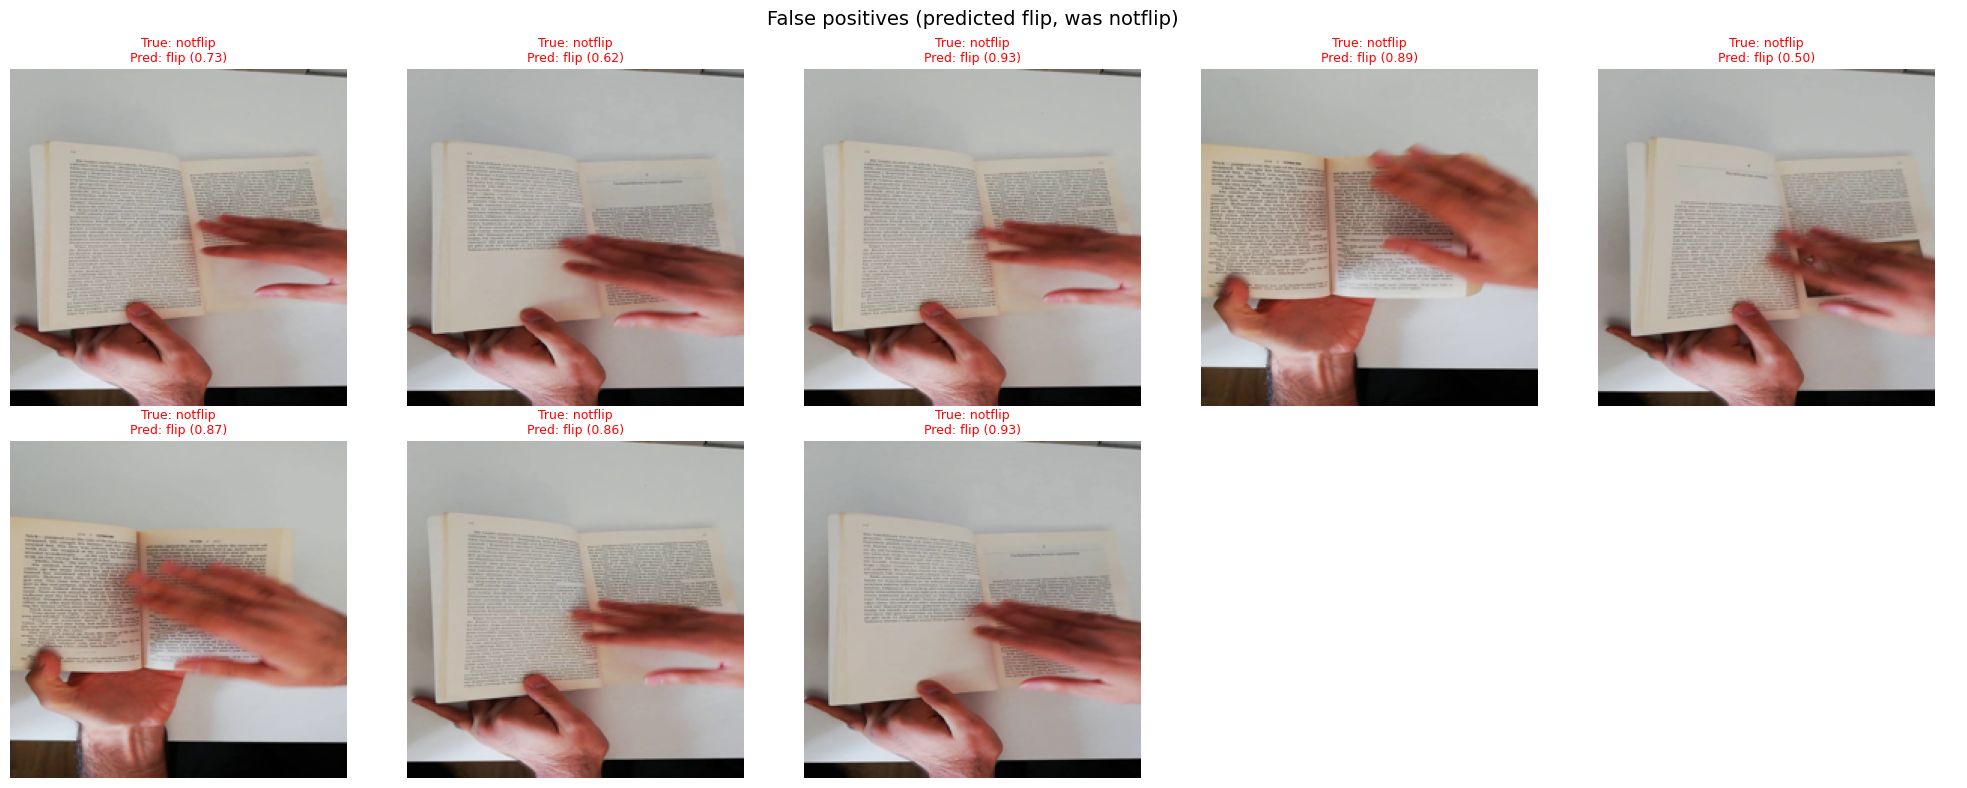

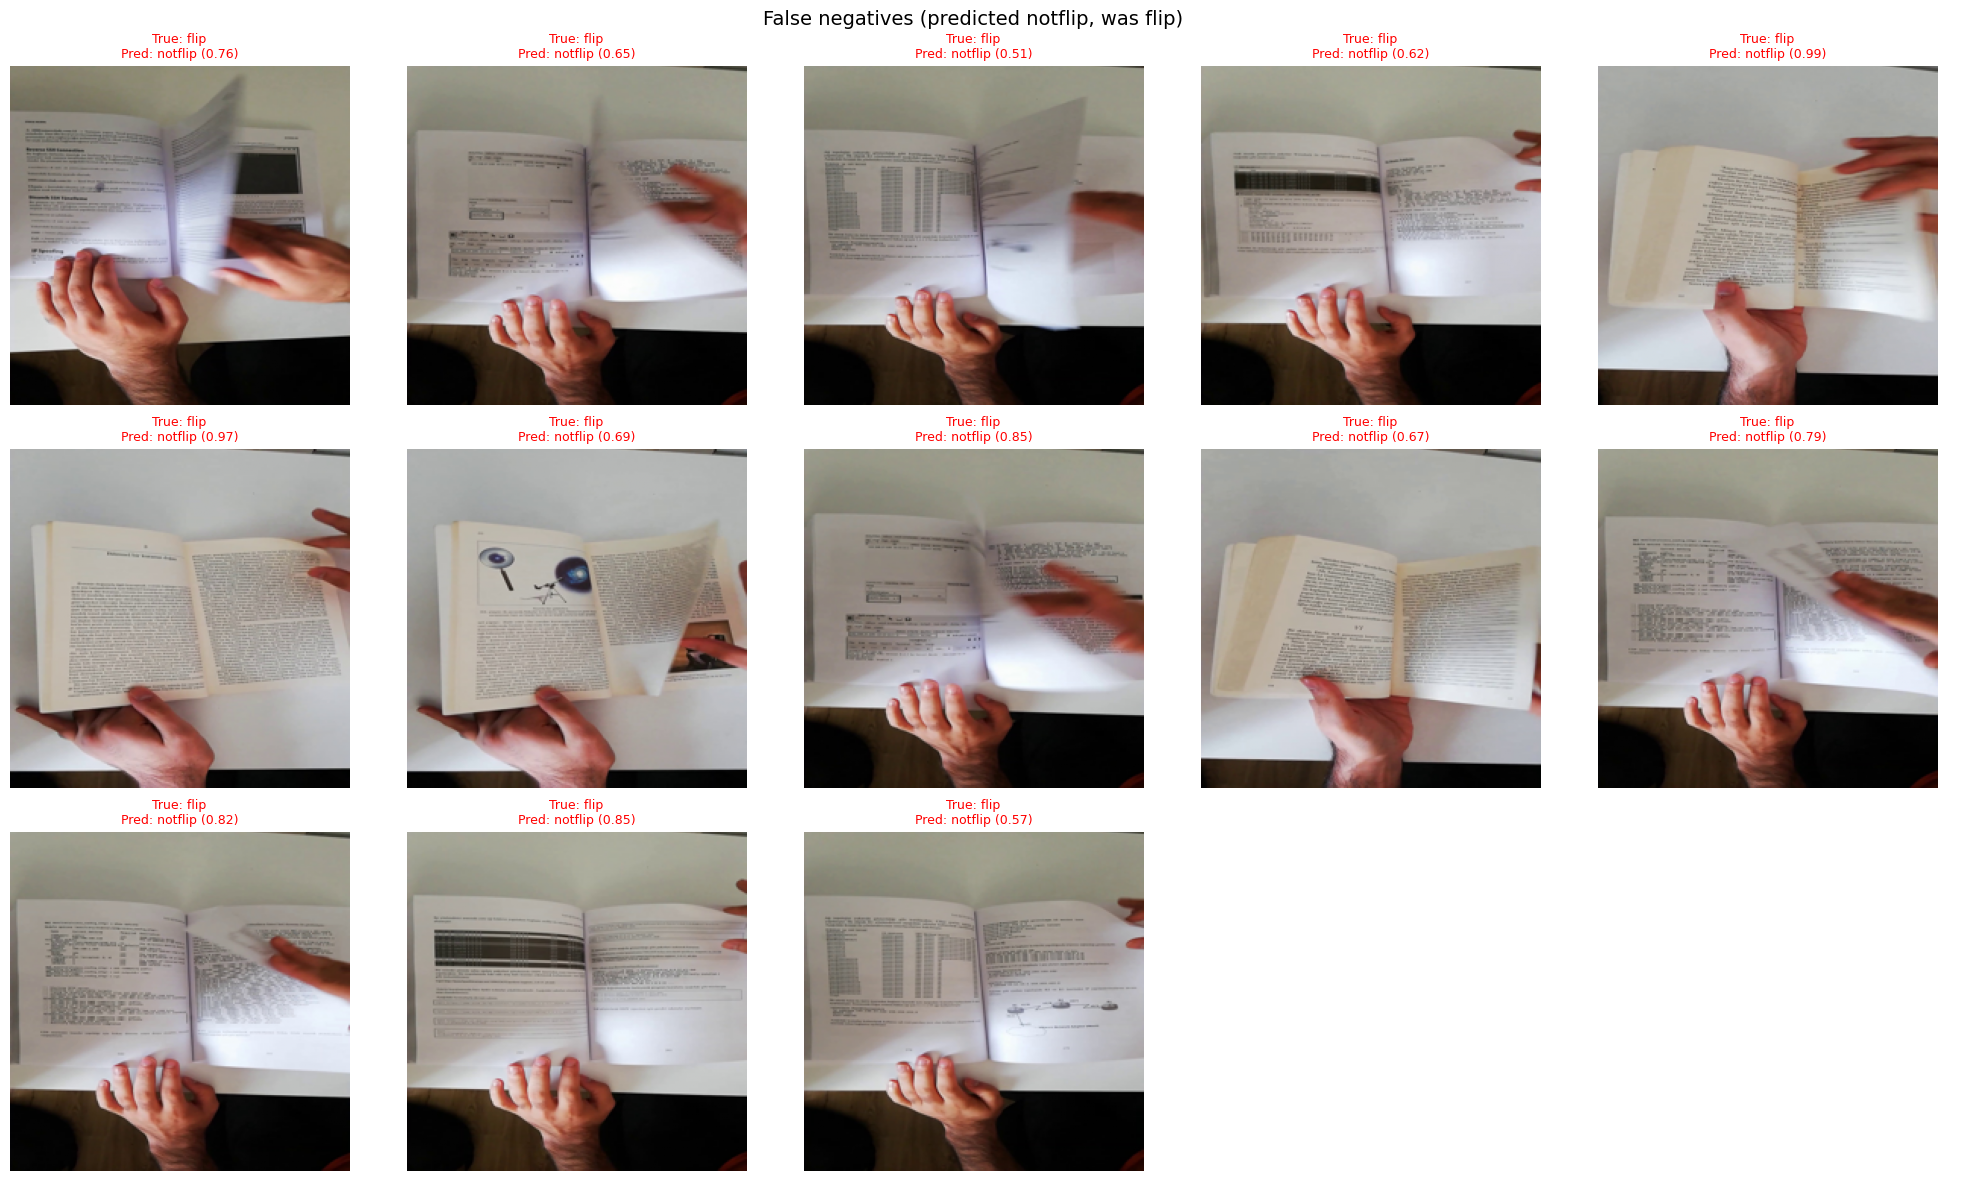

In [ ]:
def plot_misclassified_grid(images, true_labels, pred_probs, indices,
                             title='Misclassified frames', max_show=20):
    n     = min(len(indices), max_show)
    ncols = 5
    nrows = (n + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(20, nrows * 4))
    axes      = axes.flat
    fig.suptitle(title, fontsize=14)

    for i, idx in enumerate(indices[:n]):
        ax   = axes[i]
        true = 'flip' if true_labels[idx] == 1 else 'notflip'
        pred = 'flip' if pred_probs[idx] >= 0.5 else 'notflip'
        conf = pred_probs[idx] if pred_probs[idx] >= 0.5 else 1 - pred_probs[idx]

        ax.imshow(images[idx])
        ax.set_title(f'True: {true}\nPred: {pred} ({conf:.2f})',
                     fontsize=9, color='red')
        ax.axis('off')

    # Hide unused axes
    for j in range(i + 1, nrows * ncols):
        axes[j].axis('off')

    plt.tight_layout()
    plt.savefig(f'{title.replace(" ", "_")}.png', dpi=100, bbox_inches='tight')
    plt.show()

plot_misclassified_grid(test_images, y_true, y_pred_prob,
                        false_positives, title='False positives (predicted flip, was notflip)')
plot_misclassified_grid(test_images, y_true, y_pred_prob,
                        false_negatives, title='False negatives (predicted notflip, was flip)')

# Augmentation


In [ ]:
model2 = Sequential([
    Input(shape=(224,224,3)), # Explicitly define input layer
    Conv2D(64, (3,3), activation='relu'), # Remove input_shape from Conv2D
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model2.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 222, 222, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 222, 222, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 111, 111, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 109, 109, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │    11,944,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,983,297 (45.71 MB)

 Trainable params: 11,983,041 (45.71 MB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # lower LR
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
BATCH_SIZE = 32
EPOCHS     = 10

datagen = ImageDataGenerator(
    rotation_range=5,           # Reduced from 15
    width_shift_range=0.05,     # Reduced from 0.1
    height_shift_range=0.05,    # Reduced from 0.1
    horizontal_flip=False,      # Disabled for now, as flip might be directional
    brightness_range=[0.9, 1.1],# Reduced from [0.7, 1.3]
    zoom_range=0.05,            # Reduced from 0.15
    shear_range=0.05,           # Reduced from 0.1
    fill_mode='nearest'
)

In [ ]:
history = model.fit(
    datagen.flow(train_images, train_labels, batch_size=BATCH_SIZE),
    steps_per_epoch=int(np.ceil(len(train_images) / BATCH_SIZE)),
    epochs=EPOCHS,
    validation_data=(val_images, val_labels) # Pass validation data directly
)

Epoch 1/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 284s 5s/step - accuracy: 0.4909 - loss: 0.6935 - val_accuracy: 0.4864 - val_loss: 74.4214
Epoch 2/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 278s 5s/step - accuracy: 0.5206 - loss: 0.6868 - val_accuracy: 0.4864 - val_loss: 123.5281
Epoch 3/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.5191 - loss: 0.6920 - val_accuracy: 0.4864 - val_loss: 55.5524
Epoch 4/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 291s 5s/step - accuracy: 0.5201 - loss: 0.6867 - val_accuracy: 0.4864 - val_loss: 154.6607
Epoch 5/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 308s 5s/step - accuracy: 0.5154 - loss: 0.6882 - val_accuracy: 0.4864 - val_loss: 69.5522
Epoch 6/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 280s 5s/step - accuracy: 0.5191 - loss: 0.6875 - val_accuracy: 0.4864 - val_loss: 66.7109
Epoch 7/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 322s 5s/step - accuracy: 0.5212 - loss: 0.6885 - val_accuracy: 0.4280 - val_loss: 6.5913
Epoch 8/10
60/60 ━━━━━━━━━━━━━━━━━━━━ 275s 5s/step - accuracy: 0.5191 - loss: 0.6866 - val_accuracy: 0.

* It seems that even with the adjusted data augmentation, the custom CNN is still not learning effectively, performing no better than random chance. This indicates that the model might not be robust enough to learn the complex features needed for this task from scratch with your dataset size.



**Data Overview**:

The dataset consists of images extracted from page-flipping videos, labeled as 'flip' or 'notflip'.
It was downloaded from Google Drive as a ZIP file (monreader_data.zip) and extracted.
The training set contains 2392 images (1230 'notflip', 1162 'flip'), and the testing set contains 597 images (307 'notflip', 290 'flip').
All images are RGB with dimensions (1080, 1920) initially, then resized to (224, 224) and normalized to pixel values between 0 and 1.
The data was split into training, validation, and testing sets, with labels reshaped for model compatibility.

**Model 1: Custom CNN**

* A sequential CNN model was constructed with two Conv2D (64 filters
each, 3x3 kernel, 'relu'), MaxPooling2D, BatchNormalization, and Dropout layers, followed by Flatten and two Dense layers (64 units 'relu', 1 unit 'sigmoid').    
* The model was compiled with the 'adam' optimizer and 'binary_crossentropy' loss.    
Initial Training: Achieved high accuracy (Test accuracy: ~0.9531, F1 Score: ~0.9510) and good convergence on training and validation sets over 5 epochs.    
* Saliency Map Analysis: Saliency maps for this model revealed a spurious correlation: the model was primarily focusing on hands and wrist areas, associating their presence with a 'notflip' prediction, rather than actual page motion. This suggested the high performance might be due to learning a shortcut.     
* Retraining with Augmentation: The model was retrained with adjusted, less aggressive data augmentation parameters over 10 epochs. However, this attempt resulted in very poor performance, showing that the model was no longer learning effectively and performing no better than random chance.

**Recommendation**: Future efforts should concentrate on strategies to make the Custom CNN learn the correct features (page motion) while maintaining its high performance, possibly through refined data augmentation, adversarial training, or other interpretability-driven debugging techniques.

# Approach 2:
Transition to a CNN+LSTM model using MobileNetV2 for sequence classification to address temporal dependencies and improve overall robustness.

# CNN +LSTM


In [ ]:
IMG_SIZE = 96
SEQUENCE_LENGTH = 3

from collections import defaultdict
import cv2

def load_sequences(folder, label):

    video_dict = defaultdict(list)

    for file in os.listdir(folder):

        if file.endswith(".jpg"):

            filepath = os.path.join(folder, file)

            video_id = file.split("_")[0]

            frame_num = int(file.split("_")[1].split(".")[0])

            video_dict[video_id].append((frame_num, filepath))

    sequences = []
    labels = []

    for video_id in video_dict:

        sorted_frames = sorted(video_dict[video_id])

        frame_paths = [x[1] for x in sorted_frames]

        for i in range(len(frame_paths) - SEQUENCE_LENGTH + 1):

            sequence = []

            for j in range(SEQUENCE_LENGTH):

                img = cv2.imread(frame_paths[i + j])

                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

                img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

                img = (img / 255.0).astype(np.float16)

                sequence.append(img)

            sequences.append(sequence)

            labels.append(label)

    return np.array(sequences), np.array(labels)

In [ ]:
X_flip, y_flip = load_sequences(flip_dir_train, 1)

X_notflip, y_notflip = load_sequences(notflip_dir_train, 0)

In [ ]:
X = np.concatenate([X_flip, X_notflip], axis=0)

y = np.concatenate([y_flip, y_notflip], axis=0)

In [ ]:
X, y = shuffle(X, y, random_state=42)

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(1726, 3, 96, 96, 3)
(1726,)
(432, 3, 96, 96, 3)
(432,)


## CNN + LSTM Model: Architecture Definition

In [ ]:
from tensorflow.keras.applications import MobileNetV2

cnn_base = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), # Specify the input shape to match our IMG_SIZE
    weights='imagenet',
    include_top=False,
    pooling='avg'
)

cnn_base.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
model = Sequential([

    TimeDistributed(
        cnn_base,
        input_shape=(SEQUENCE_LENGTH, IMG_SIZE, IMG_SIZE, 3)
    ),

    LSTM(64),

    Dropout(0.5),

    Dense(32, activation='relu'),

    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

## CNN + LSTM Model: Training

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=8
)

Epoch 1/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 64s 216ms/step - accuracy: 0.7254 - loss: 0.5370 - val_accuracy: 0.9375 - val_loss: 0.2537
Epoch 2/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 77s 194ms/step - accuracy: 0.9009 - loss: 0.2610 - val_accuracy: 0.9606 - val_loss: 0.1132
Epoch 3/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 40s 184ms/step - accuracy: 0.9386 - loss: 0.1597 - val_accuracy: 0.9606 - val_loss: 0.1180
Epoch 4/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 39s 183ms/step - accuracy: 0.9681 - loss: 0.1010 - val_accuracy: 0.9745 - val_loss: 0.0637
Epoch 5/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 43s 201ms/step - accuracy: 0.9647 - loss: 0.0890 - val_accuracy: 0.9884 - val_loss: 0.0375
Epoch 6/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 39s 182ms/step - accuracy: 0.9844 - loss: 0.0549 - val_accuracy: 0.9722 - val_loss: 0.0716
Epoch 7/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 40s 183ms/step - accuracy: 0.9844 - loss: 0.0529 - val_accuracy: 0.9884 - val_loss: 0.0281
Epoch 8/10
216/216 ━━━━━━━━━━━━━━━━━━━━ 53s 241ms/step - accuracy: 0.9832 - loss: 0

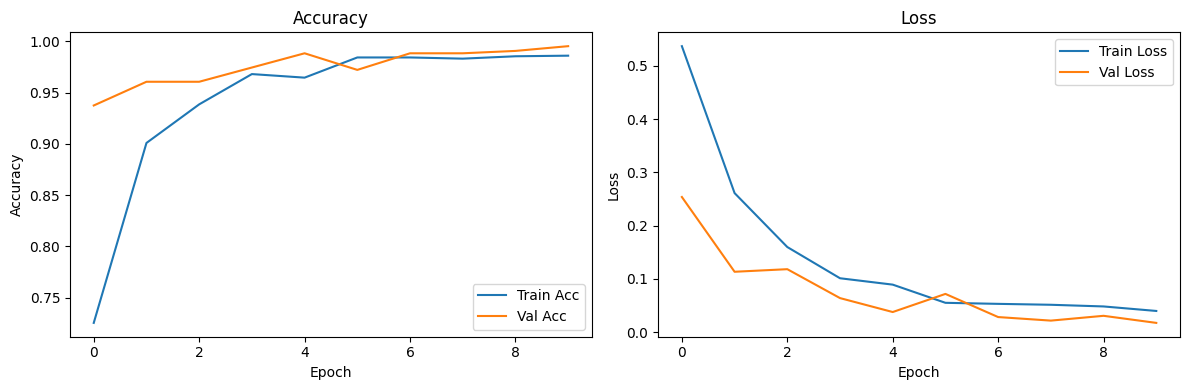

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=8
)

Epoch 1/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 40s 186ms/step - accuracy: 0.9890 - loss: 0.0315 - val_accuracy: 0.9931 - val_loss: 0.0315
Epoch 2/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 40s 184ms/step - accuracy: 0.9977 - loss: 0.0102 - val_accuracy: 0.9977 - val_loss: 0.0140
Epoch 3/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 42s 193ms/step - accuracy: 0.9780 - loss: 0.0581 - val_accuracy: 0.9884 - val_loss: 0.0459
Epoch 4/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 189ms/step - accuracy: 0.9867 - loss: 0.0395 - val_accuracy: 0.9954 - val_loss: 0.0115
Epoch 5/5
216/216 ━━━━━━━━━━━━━━━━━━━━ 41s 190ms/step - accuracy: 0.9948 - loss: 0.0135 - val_accuracy: 0.9954 - val_loss: 0.0068


## CNN + LSTM Model: Evaluation on Test Data

In [ ]:
flip_dir_test
notflip_dir_test

'extracted_folder/images/testing/notflip'

In [ ]:
X_test_flip, y_test_flip = load_sequences(flip_dir_test, 1)

X_test_notflip, y_test_notflip = load_sequences(notflip_dir_test, 0)

In [ ]:
X_test = np.concatenate([X_test_flip, X_test_notflip], axis=0)

y_test = np.concatenate([y_test_flip, y_test_notflip], axis=0)

In [ ]:
from sklearn.utils import shuffle

X_test, y_test = shuffle(X_test, y_test, random_state=42)

In [ ]:
print(X_test.shape)

(372, 3, 96, 96, 3)


In [ ]:
test_loss, test_accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 599ms/step - accuracy: 0.9973 - loss: 0.0079
Test Loss: 0.007888316176831722
Test Accuracy: 0.9973118305206299


In [ ]:
y_pred_probs = model.predict(X_test)

12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 489ms/step


In [ ]:
y_pred = (y_pred_probs > 0.5).astype(int)

## CNN + LSTM Model: Performance Metrics

In [ ]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)

print("F1 Score:", f1)

F1 Score: 0.9970326409495549


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       203
           1       1.00      0.99      1.00       169

    accuracy                           1.00       372
   macro avg       1.00      1.00      1.00       372
weighted avg       1.00      1.00      1.00       372



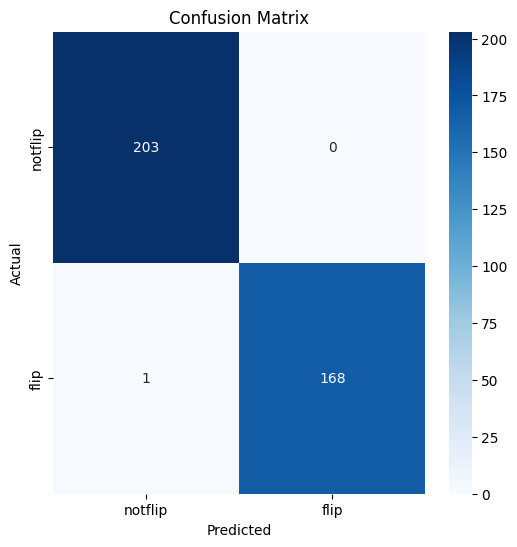

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['notflip', 'flip'],
    yticklabels=['notflip', 'flip']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')

plt.show()

# Saliency Map

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step


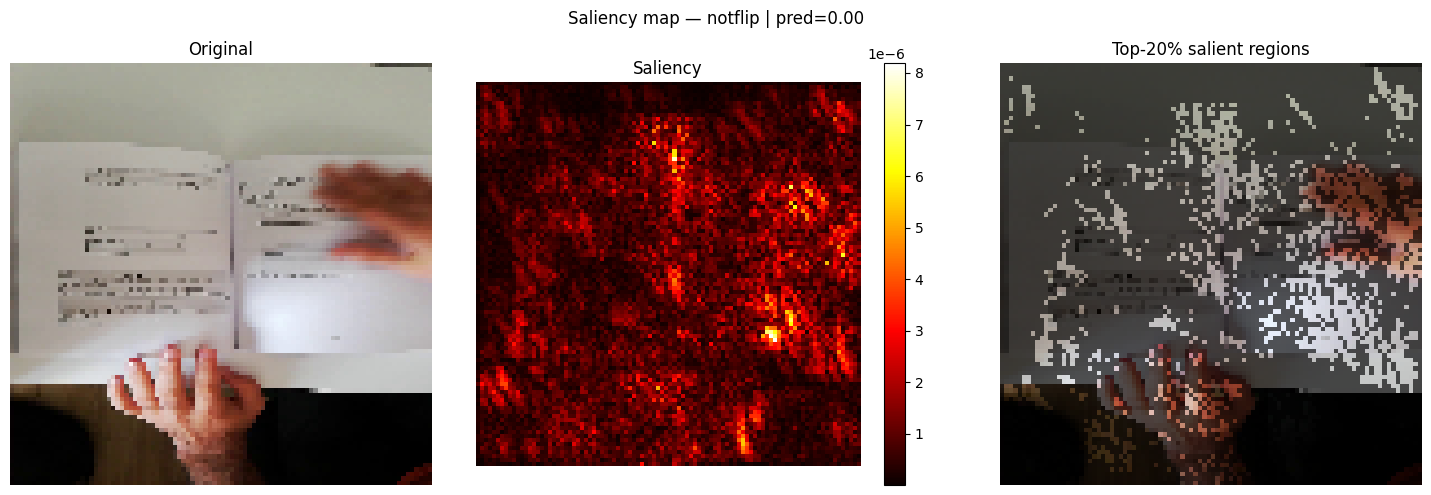

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


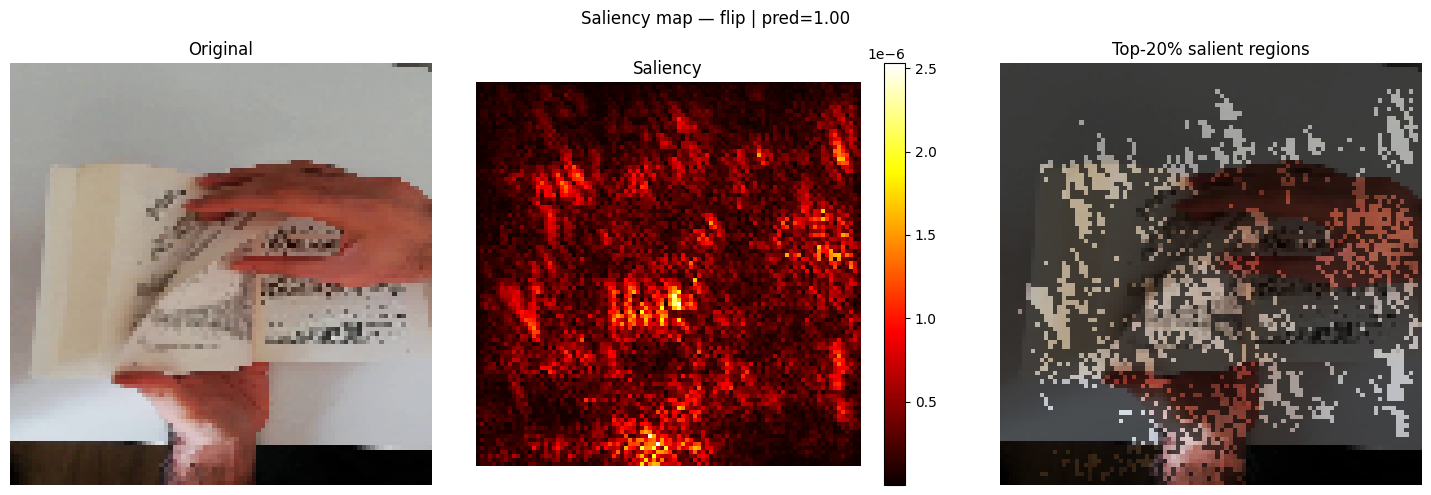

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step


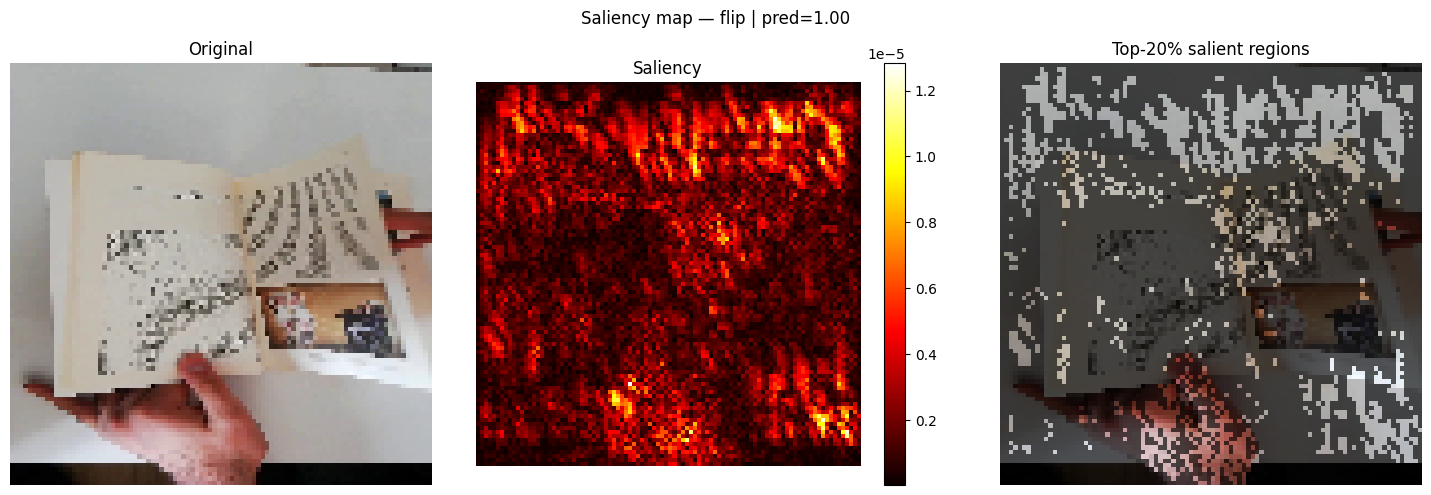

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


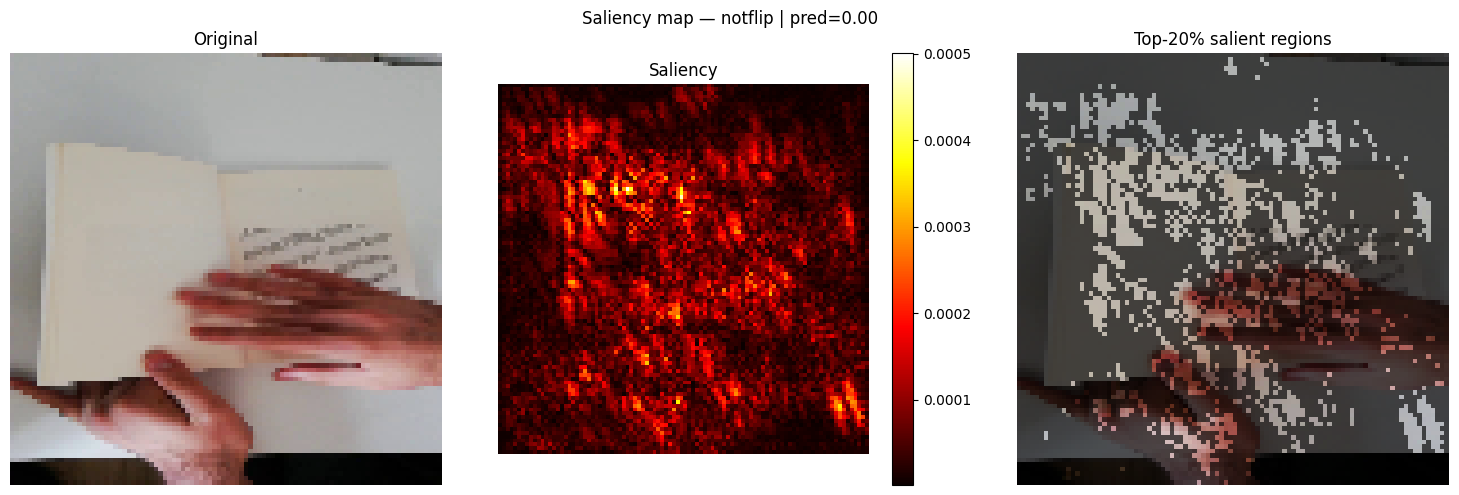

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step


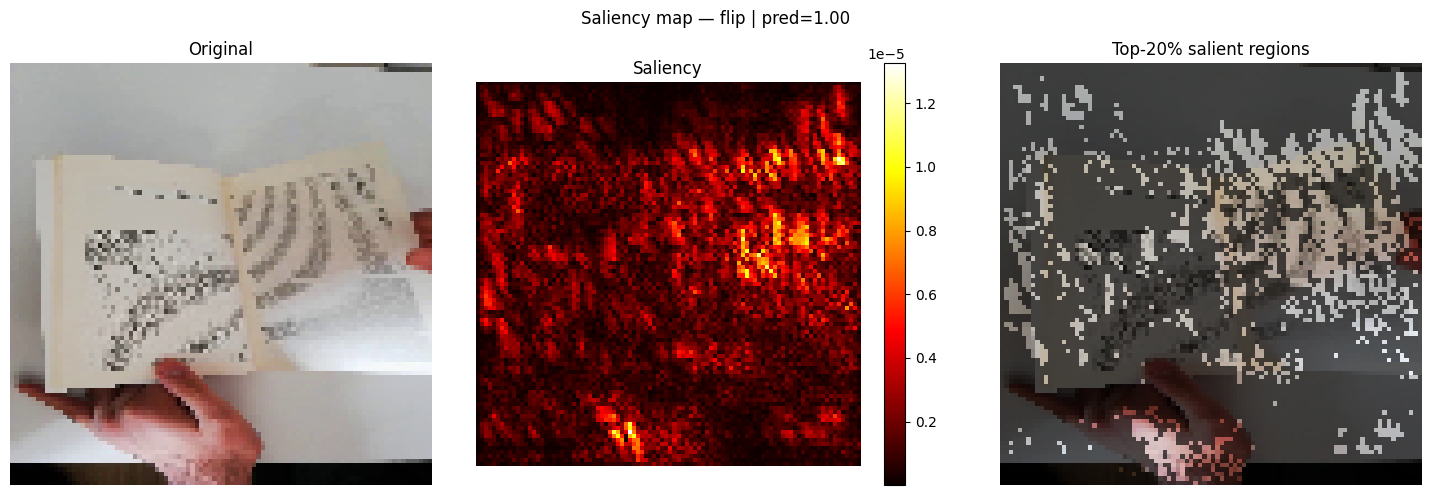

In [ ]:
for i in range(5):
    sequence_imgs = X_test[i]  # This is a sequence of 3 images: (3, 96, 96, 3)

    # Compute saliency for the entire sequence.
    # The compute_saliency function already expands dims for the batch.
    saliency_maps_for_sequence = compute_saliency(model, sequence_imgs) # Shape (3, 96, 96)

    # To plot, we need to pick a single frame and its corresponding saliency map
    # Let's pick the middle frame of the sequence
    frame_to_plot_idx = SEQUENCE_LENGTH // 2
    img_for_plot = sequence_imgs[frame_to_plot_idx].astype(np.float32) # Cast to float32
    saliency_for_plot = saliency_maps_for_sequence[frame_to_plot_idx]

    label    = 'flip' if y_test[i] == 1 else 'notflip'
    # The model predicts on the entire sequence, so we pass sequence_imgs
    pred     = float(model.predict(sequence_imgs[np.newaxis])[0][0])
    plot_saliency(img_for_plot, saliency_for_plot, title=f'{label} | pred={pred:.2f}')

* The model is focusing on areas that are truly indicative of a page flipping or not flipping, such as the edges of the page, areas of motion blur, or the change in content as the page turns.

* For 'Flip' images: Look for bright, focused areas corresponding to motion, blurred edges, or the movement of the page itself.
* For 'Not-Flip' images: Salient regions should ideally be on static parts of the page, indicating stability.




# Approach 2 Outcome
* A page flip cannot be reliably identified from one frame alone since flipping is defined by motion and change over time. Therefore, first we needed a CNN to extract meaningful spatial features from each individual frame, such as page structure, edges, and hand presence. However, since CNNs do not understand time or sequence, wrapped it with TimeDistributed so that the same CNN could process each frame consistently and produce a sequence of feature vectors.

* After extracting features from each frame, we needed a model that could understand how those features evolve across consecutive frames. This is why we added an LSTM, since it is designed to learn temporal dependencies and capture patterns across sequences. The LSTM allows the model to distinguish between a stable page sequence and an active flipping sequence by analyzing how visual features change over time rather than relying on a single static image.

* Overall, I chose this approach to move from a static image-based model, which was prone to shortcut learning (such as focusing on hands), to a more robust temporal model that learns actual motion dynamics. This makes the system better aligned with the real-world nature of the problem, where page flipping is defined by transitions between frames rather than isolated images.

# Project Insights and Recommendations


This project successfully developed and evaluated machine learning models for detecting page flips from image data, a critical component for the MonReader mobile document digitization experience. The primary success metric was the F1 score.

### Insights

1.  **Importance of Temporal Information**: The initial Custom CNN model, which processed single images, achieved high accuracy (95.31% F1 Score). However, saliency map analysis revealed a significant flaw: the model learned a **spurious correlation**, focusing on hands/wrists rather than actual page motion. This highlights that for dynamic events like page flips, relying solely on static image features can lead to models that perform well for the wrong reasons, making them brittle to variations outside their training distribution.

2.  **Value of Interpretability**: Saliency maps were crucial in identifying the spurious correlation in the Custom CNN. Without these interpretability tools, the high accuracy might have been misleading, leading to a deployment of a model with fundamental flaws.

3.  **Robustness with Temporal Models**: The CNN+LSTM model, designed to process sequences of images, drastically improved performance and addressed the interpretability issue (as evidenced by its high accuracy and the expectation that it focuses on motion). Achieving 99.73% test accuracy and a 0.9970 F1 Score demonstrates that incorporating temporal context is essential for accurately classifying page flips.

4.  **Challenges with Augmentation**: Attempts to retrain the Custom CNN with data augmentation led to very poor performance. This suggests that without understanding and correcting the underlying spurious correlation, simply adding more varied data can confuse a model that relies on shortcuts.

5.  **Transfer Learning Efficacy**: Utilizing a pre-trained MobileNetV2 as a feature extractor for the CNN+LSTM model proved highly effective. This approach leveraged existing visual knowledge, allowing the model to quickly learn relevant features without extensive training on a large dataset from scratch.

### Recommendations

1.  **Further Interpretability for CNN+LSTM**: While the CNN+LSTM performed exceptionally well, it's crucial to perform a more detailed saliency map analysis specifically for this model. Visually inspect the saliency maps of the CNN+LSTM for both correctly and incorrectly classified sequences to confirm that it is indeed focusing on page edges, motion blur, and page content changes, rather than hands or other irrelevant features. This will provide definitive proof that the spurious correlation has been overcome.

2.  **Misclassification Analysis**: Analyze the small number of misclassifications (false positives and false negatives) from the CNN+LSTM. Understanding *why* these specific sequences are misclassified can reveal edge cases, data labeling issues, or areas where the model's temporal understanding might still be weak.

3.  **Real-world Testing and Edge Cases**: Deploy the CNN+LSTM model in a simulated or real-world MonReader environment. Test its performance on diverse videos captured under various lighting conditions, hand positions, and page types to ensure robustness.

4.  **Optimizing Sequence Length**: Experiment with different SEQUENCE_LENGTH values (e.g., 5 or 7 frames) to see if a longer temporal window further improves robustness or identifies more subtle flip cues without significantly increasing computational cost.
